In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

#Read data
pd.set_option('display.max_columns', None)
data = pd.read_csv('globalterrorismdb_0221dist.csv', skiprows=[1], skipinitialspace=True)


#Subset my interested columns
df = data[['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'country_txt', 'region_txt', 'crit1', 'crit2', 'crit3', 'attacktype1_txt', 
           'attacktype2_txt', 'attacktype3_txt', 'targtype1_txt', 'targtype2_txt', 'targtype3_txt', 'gname', 'claimed',
           'weaptype1_txt', 'weaptype2_txt', 'weaptype3_txt', 'nkill','individual','success', 'ishostkid', 'property',
           'nwound', 'extended', 'resolution','INT_LOG', 'INT_IDEO', 'INT_MISC', 'INT_ANY']]

df_post2012 = df[df['iyear'] >= 2012]

# 18% unknown (-9)
df_post2012['property']  = df_post2012['property'].replace(-9, np.nan).fillna(0).astype(int)

# 0.44% unknown - can drop
df_post2012['ishostkid'] = df_post2012['ishostkid'].replace(-9, np.nan)
df_post2012 = df_post2012.dropna(subset=['ishostkid'])
df_post2012['ishostkid'] = df_post2012['ishostkid'].astype(int)

# About 10% null, since target value we should drop to preserve data integrity
df_post2012 = df_post2012.dropna(subset=['nkill', 'nwound'])

print("HERE")
print(df_post2012.info())

#Make a log transformed column for these values to deal with high variance data
df_post2012['log_nkill'] = np.log1p(df_post2012['nkill'])
df_post2012['log_nwound'] = np.log1p(df_post2012['nwound'])

df_post2012['violence_level'] = (2 * df_post2012['nkill'] + df_post2012['nwound'])
df_post2012.info()
#Cut out the top .03% of events by violence level to clean up severe outliers.
p = 0.997
threshold = df_post2012['violence_level'].quantile(p)
df_trimmed = df_post2012[df_post2012['violence_level'] <= threshold]
df_trimmed.info()

C:\Users\alist\AppData\Local\Temp\ipykernel_23776\1847792227.py:10: DtypeWarning: Columns (4,31,33,54,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('globalterrorismdb_0221dist.csv', skiprows=[1], skipinitialspace=True)


HERE
<class 'pandas.core.frame.DataFrame'>
Index: 86757 entries, 104785 to 201181
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   eventid          86757 non-null  int64  
 1   iyear            86757 non-null  int64  
 2   imonth           86757 non-null  int64  
 3   iday             86757 non-null  int64  
 4   approxdate       9764 non-null   object 
 5   country_txt      86757 non-null  object 
 6   region_txt       86757 non-null  object 
 7   crit1            86757 non-null  int64  
 8   crit2            86757 non-null  int64  
 9   crit3            86757 non-null  int64  
 10  attacktype1_txt  86757 non-null  object 
 11  attacktype2_txt  3316 non-null   object 
 12  attacktype3_txt  182 non-null    object 
 13  targtype1_txt    86757 non-null  object 
 14  targtype2_txt    7561 non-null   object 
 15  targtype3_txt    710 non-null    object 
 16  gname            86757 non-null  object 
 17  claime

C:\Users\alist\AppData\Local\Temp\ipykernel_23776\1847792227.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_post2012['property']  = df_post2012['property'].replace(-9, np.nan).fillna(0).astype(int)
C:\Users\alist\AppData\Local\Temp\ipykernel_23776\1847792227.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_post2012['ishostkid'] = df_post2012['ishostkid'].replace(-9, np.nan)


## Examine Distribution of Violence Level

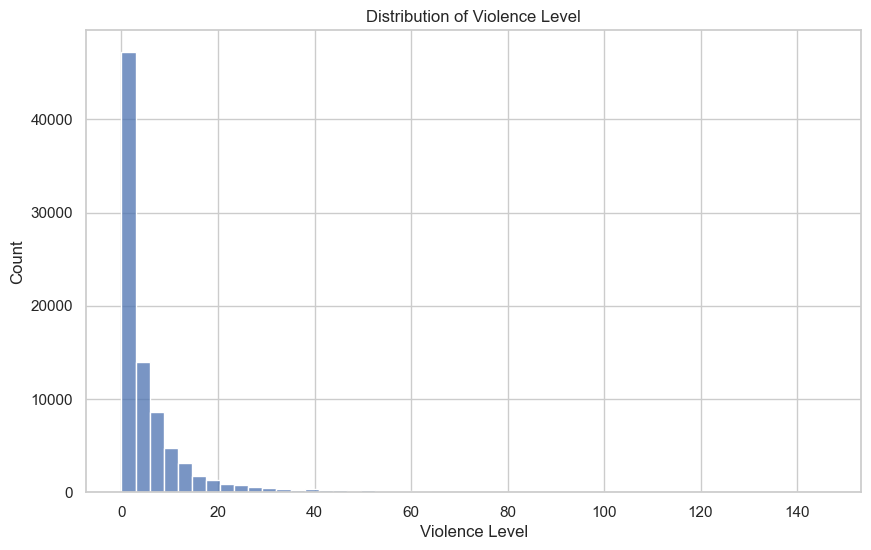

In [13]:
#Build distribution plot for Violence Level
plt.figure(figsize=(10,6))
sns.histplot(df_trimmed['violence_level'], bins=50)
plt.title('Distribution of Violence Level')
plt.xlabel('Violence Level')
plt.ylabel('Count')
plt.show()

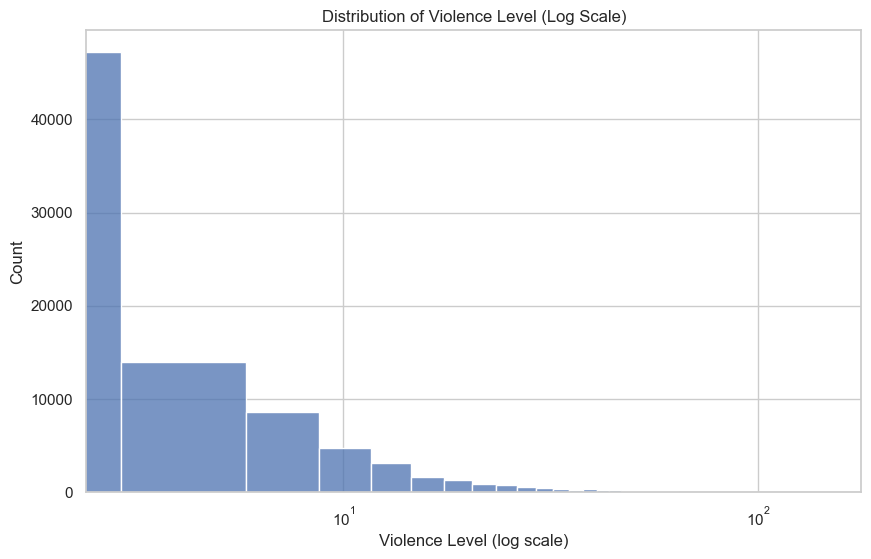

In [14]:
#Build distribution plot for log transformed Violence Level
plt.figure(figsize=(10,6))
sns.histplot(df_trimmed['violence_level'], bins=50)
plt.xscale('log')
plt.title('Distribution of Violence Level (Log Scale)')
plt.xlabel('Violence Level (log scale)')
plt.ylabel('Count')
plt.show()

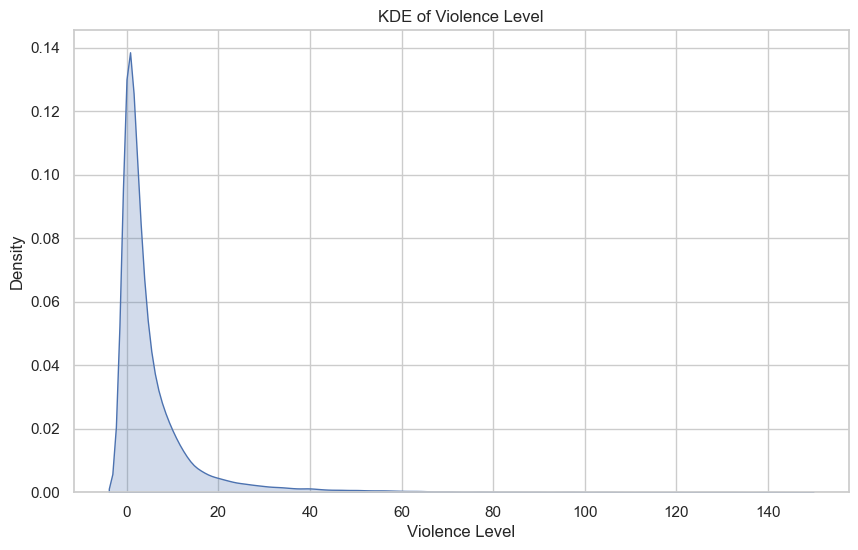

In [15]:
#Build smoothed distribution plot for Violence Level
plt.figure(figsize=(10,6))
sns.kdeplot(df_trimmed['violence_level'], fill=True)
plt.title('KDE of Violence Level')
plt.xlabel('Violence Level')
plt.show()

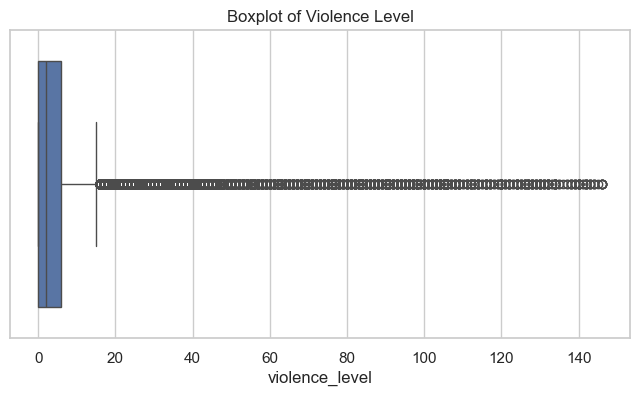

In [16]:
#Build Boxplot of Violence level
plt.figure(figsize=(8,4))
sns.boxplot(x=df_trimmed['violence_level'])
plt.title('Boxplot of Violence Level')
plt.show()

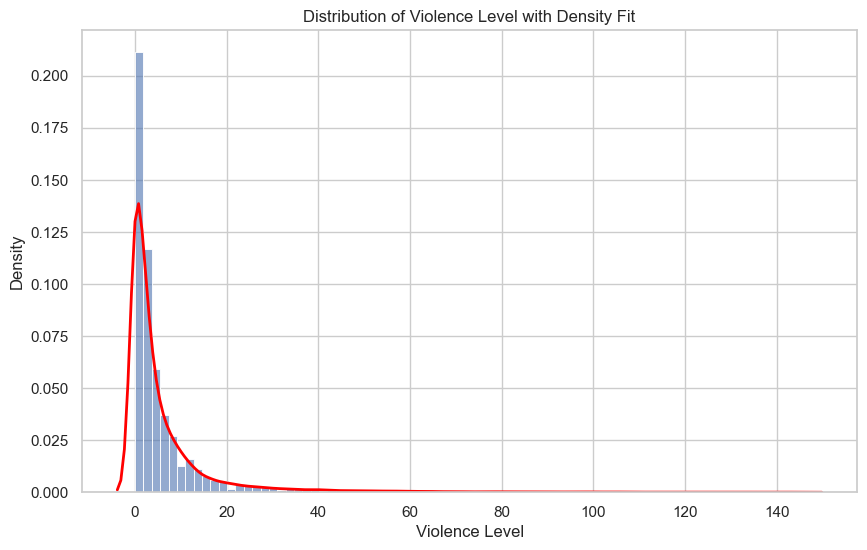

In [17]:
#Grab distribution plot with density fit for presentation
plt.figure(figsize=(10,6))
sns.histplot(df_trimmed['violence_level'], bins=80, stat='density', alpha=0.6)
sns.kdeplot(df_trimmed['violence_level'], color='red', linewidth=2)

plt.title('Distribution of Violence Level with Density Fit')
plt.xlabel('Violence Level')
plt.ylabel('Density')
plt.show()

## Time Series of attacks

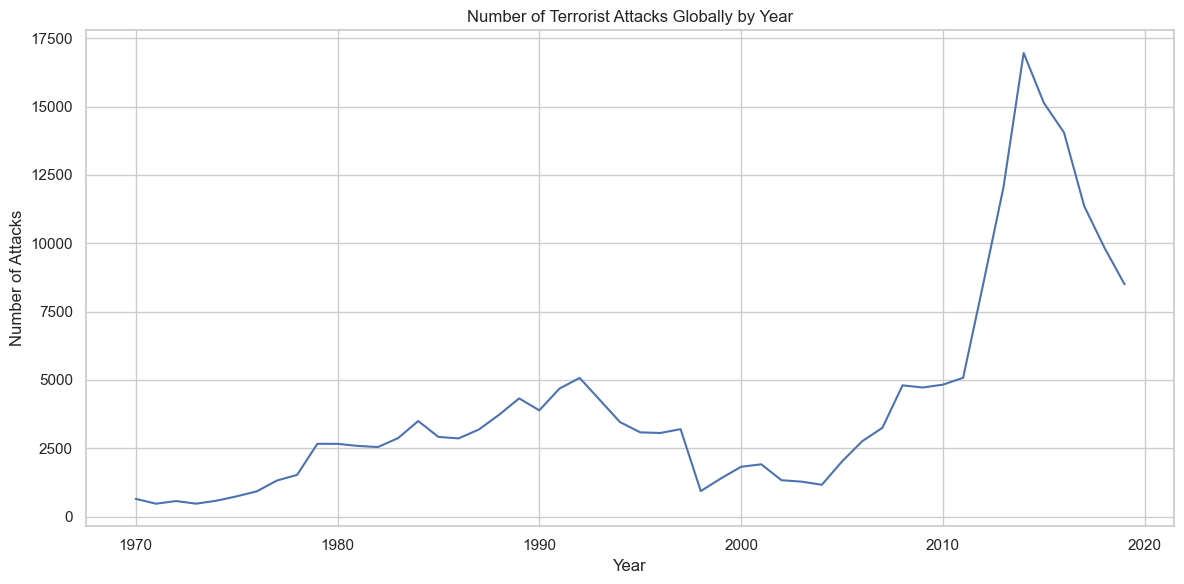

In [19]:
#Time series of attacks per year
attacks_per_year = (
    df.groupby("iyear")
      .size()
      .reset_index(name="attack_count")
)

plt.figure(figsize=(12, 6))

plt.plot(
    attacks_per_year["iyear"],
    attacks_per_year["attack_count"]
)

plt.title("Number of Terrorist Attacks Globally by Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.grid(True)
plt.tight_layout()

plt.show()

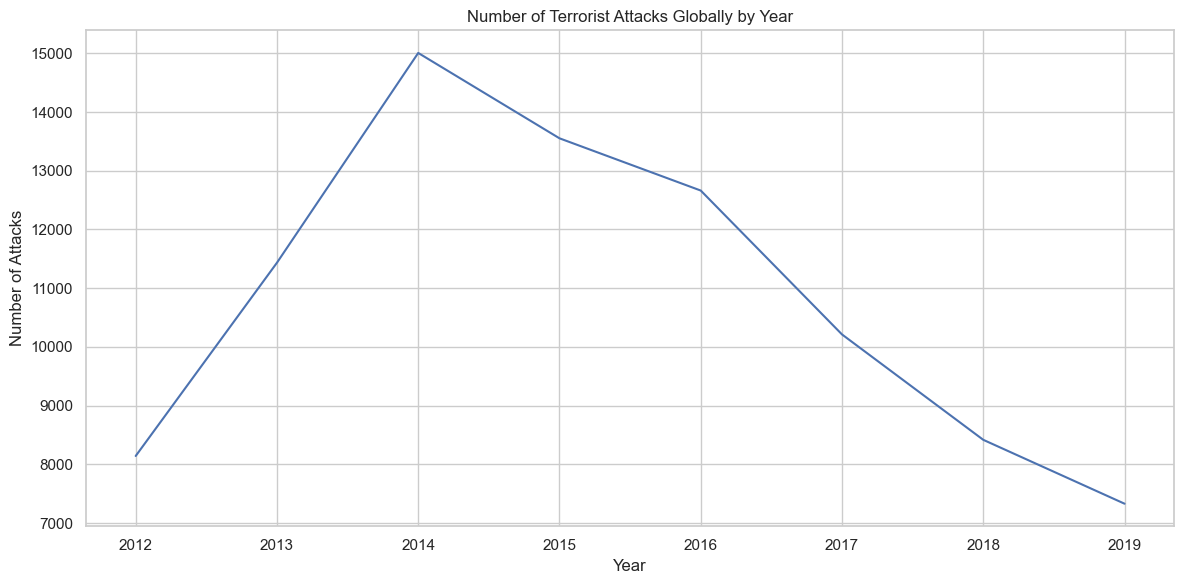

In [20]:
#Closer look at the range we focused on
attacks_per_year = (
    df_post2012.groupby("iyear")
      .size()
      .reset_index(name="attack_count")
)

plt.figure(figsize=(12, 6))

plt.plot(
    attacks_per_year["iyear"],
    attacks_per_year["attack_count"]
)

plt.title("Number of Terrorist Attacks Globally by Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.grid(True)
plt.tight_layout()

plt.show()

## Heatmaps for Region data

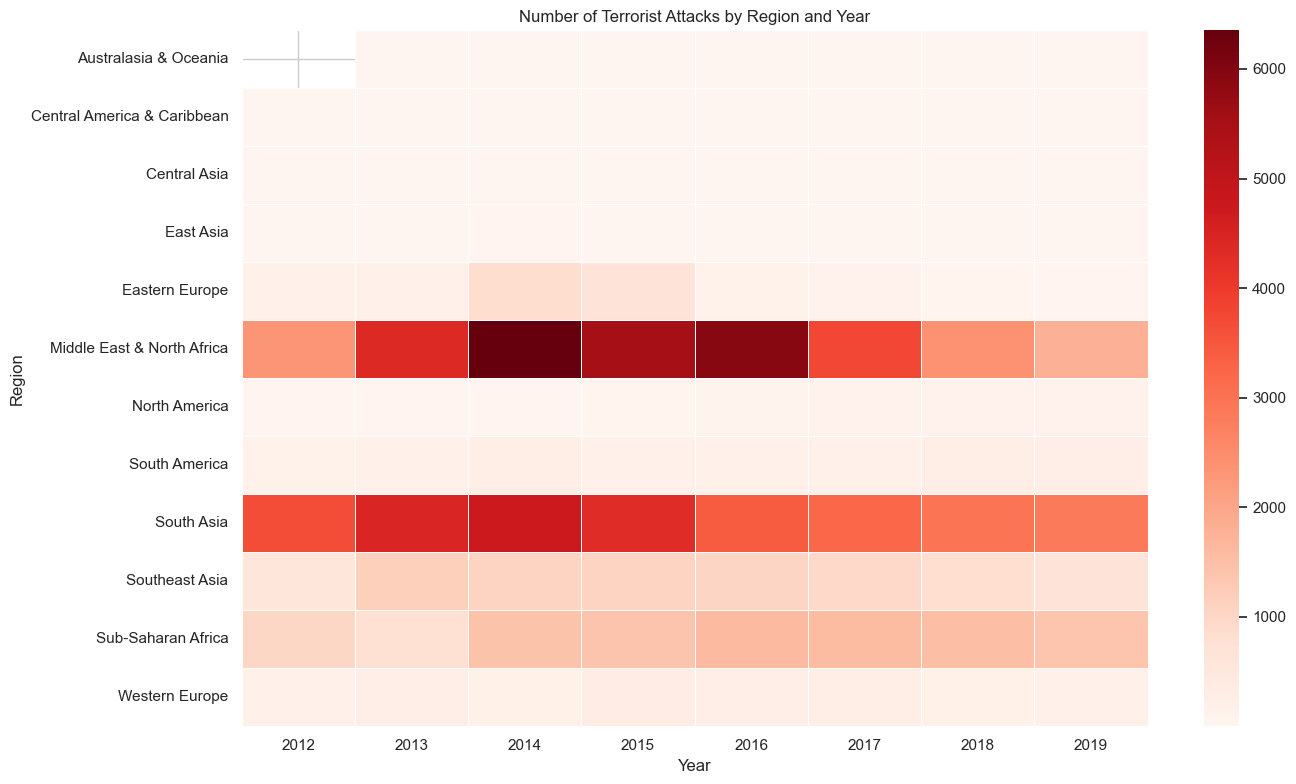

In [22]:
#Build a heatmap for number of attacks by region
attacks = (df_post2012.groupby(['region_txt', 'iyear']).size().reset_index(name="attack_count"))

heatmap_data = attacks.pivot(
    index="region_txt",
    columns="iyear",
    values="attack_count"
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    linewidths=0.5
)

plt.title("Number of Terrorist Attacks by Region and Year")
plt.xlabel("Year")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

<Axes: xlabel='iyear', ylabel='region_txt'>

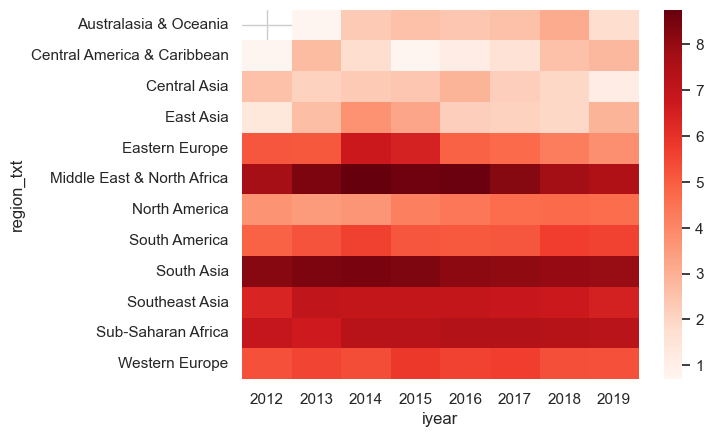

In [23]:
#Because the number of attacks in the middle east and north africa (Specically from 2013-2017)
#cause heavy bias in the graph I tried a log scaled graph so that comparing the other regions/times was easier.
sns.heatmap(
    np.log1p(heatmap_data),
    cmap="Reds"
)

## Scatterplots for nkill vs nwound

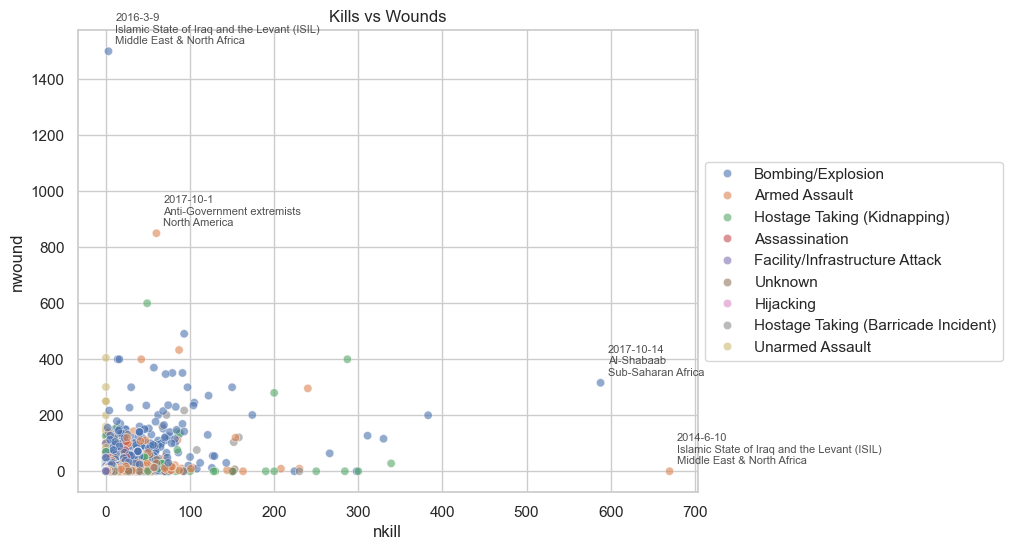

In [25]:
#Plot a scatterplot of nkill vs nwound
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_post2012,
    x='nkill',
    y='nwound',
    hue='attacktype1_txt',
    alpha=0.6
)
plt.title("Kills vs Wounds")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


#Find and label the most extreme outliers
outliers = df_post2012[
    (df_post2012['nkill'] > 400) | 
    (df_post2012['nwound'] > 600)
]

for _, row in outliers.iterrows():
    label = f"{int(row['iyear'])}-{int(row['imonth'])}-{int(row['iday'])}\n{row['gname']}\n{row['region_txt']}"
    
    plt.annotate(
        label,
        (row['nkill'], row['nwound']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        alpha=0.8
    )

plt.show()

#2017-10-1 --- Las Vegas Shooting
#2014-6-10 --- Execution of 600+ prisoners by ISIL (ISIS) (Badush Prison Massacre)
#2016-3-9 --- Chemical weapon attack on Iraqi town of Taza
#2017-10-14 --- Bombing in Somalia


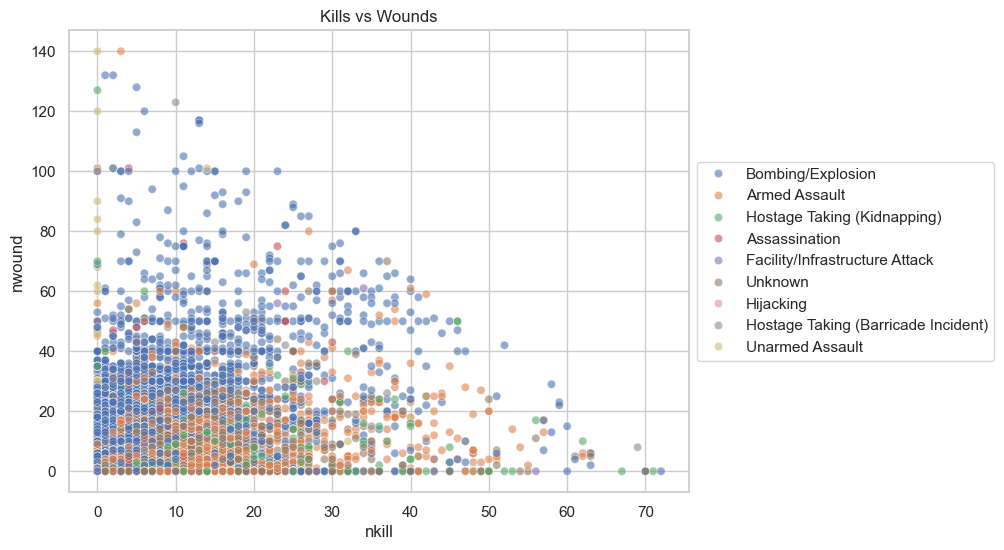

In [27]:
#Cut out the top .03% of events by violence level to clean up severe outliers.
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_trimmed,
    x='nkill',
    y='nwound',
    hue='attacktype1_txt',
    alpha=0.6
)
plt.title("Kills vs Wounds")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


plt.show()

## Comparing Mean and Median for important statistics

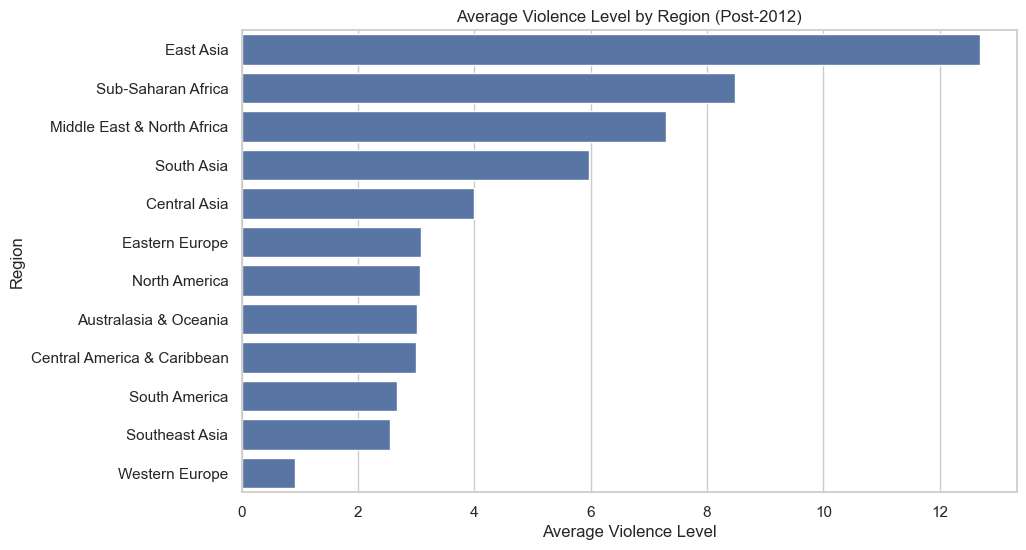

In [30]:
#Make histogram of mean violence by region
region_avg = (
    df_trimmed
    .groupby('region_txt')['violence_level']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_avg.values,
    y=region_avg.index
)

plt.xlabel("Average Violence Level")
plt.ylabel("Region")
plt.title("Average Violence Level by Region (Post-2012)")

plt.show()

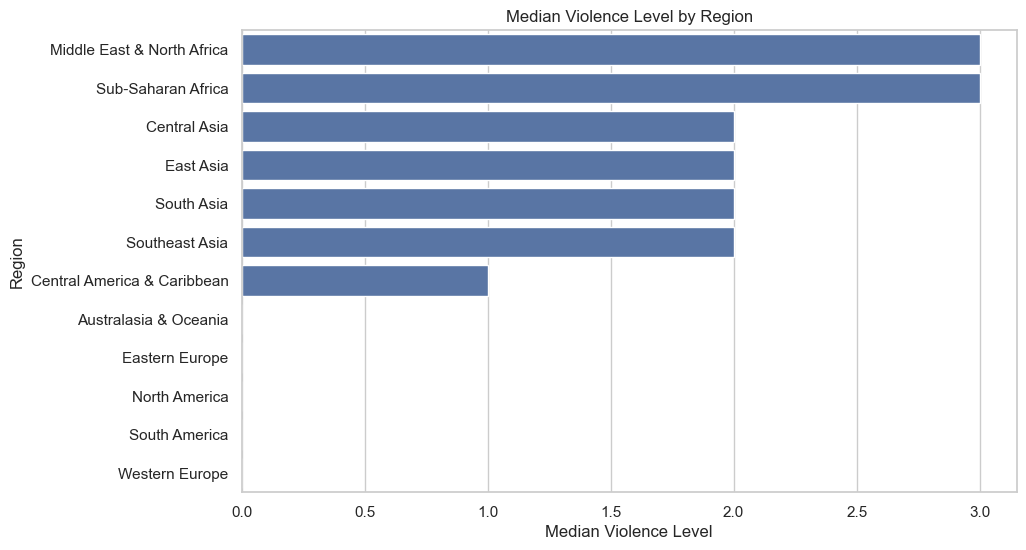

In [31]:
#Make histogram of median violence by region
region_avg = (
    df_trimmed
    .groupby('region_txt')['violence_level']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_avg.values,
    y=region_avg.index
)

plt.xlabel("Median Violence Level")
plt.ylabel("Region")
plt.title("Median Violence Level by Region")

plt.show()

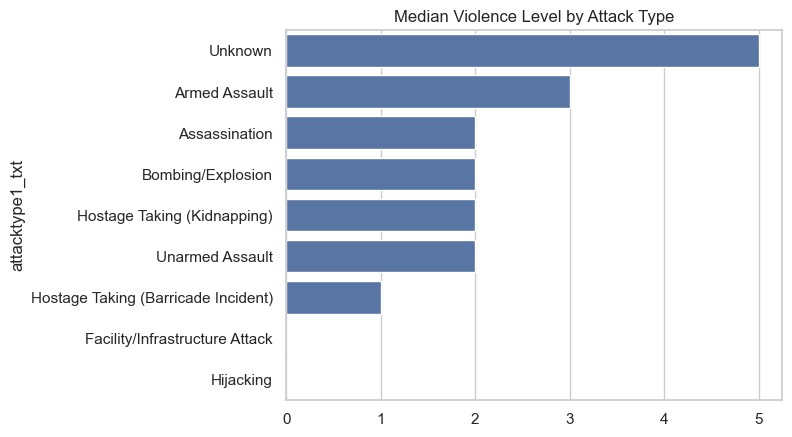

In [33]:
#Make histogram of median violence by Attack Type
attack_avg = (
    df_trimmed
    .groupby('attacktype1_txt')['violence_level']
    .median()
    .sort_values(ascending=False)
)

top_attack_avg = attack_avg.head(10)

sns.barplot(x=top_attack_avg.values, y=top_attack_avg.index)
plt.title("Median Violence Level by Attack Type")
plt.show()


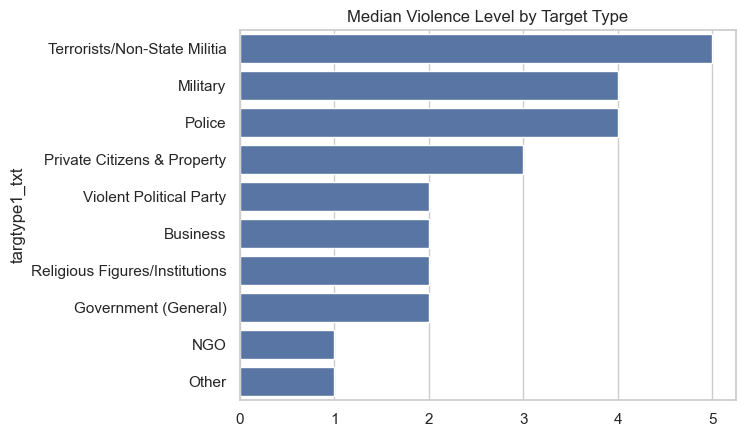

In [34]:
#Make histogram of median violence by Target Type
target_avg = (
    df_trimmed
    .groupby('targtype1_txt')['violence_level']
    .median()
    .sort_values(ascending=False)
)

top_target_avg = target_avg.head(10)

sns.barplot(x=top_target_avg.values, y=top_target_avg.index)
plt.title("Median Violence Level by Target Type")
plt.show()

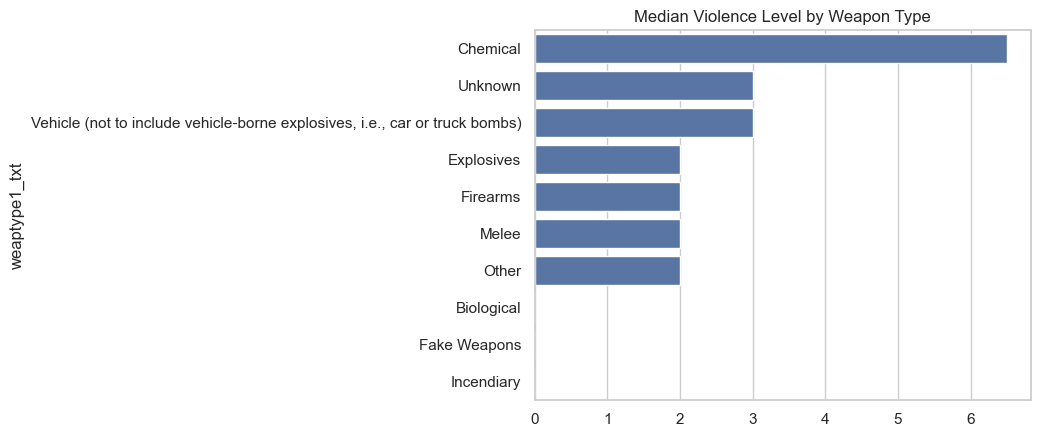

In [35]:
#Make histogram of median violence by Weapon Type
weapon_avg = (
    df_trimmed
    .groupby('weaptype1_txt')['violence_level']
    .median()
    .sort_values(ascending=False)
)

top_weapon_avg = weapon_avg.head(10)

sns.barplot(x=top_weapon_avg.values, y=top_weapon_avg.index)
plt.title("Median Violence Level by Weapon Type")
plt.show()

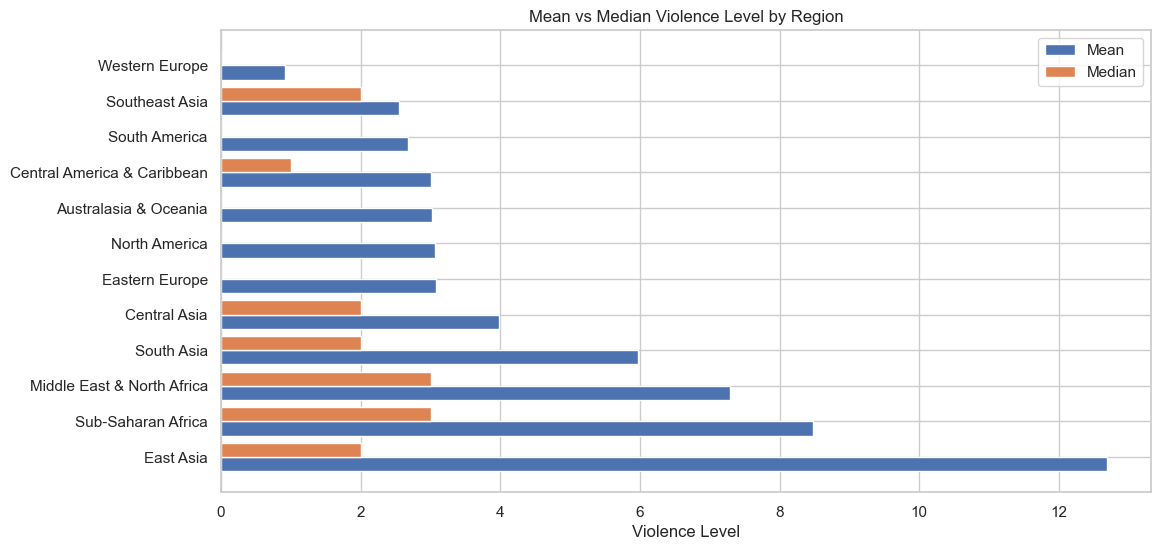

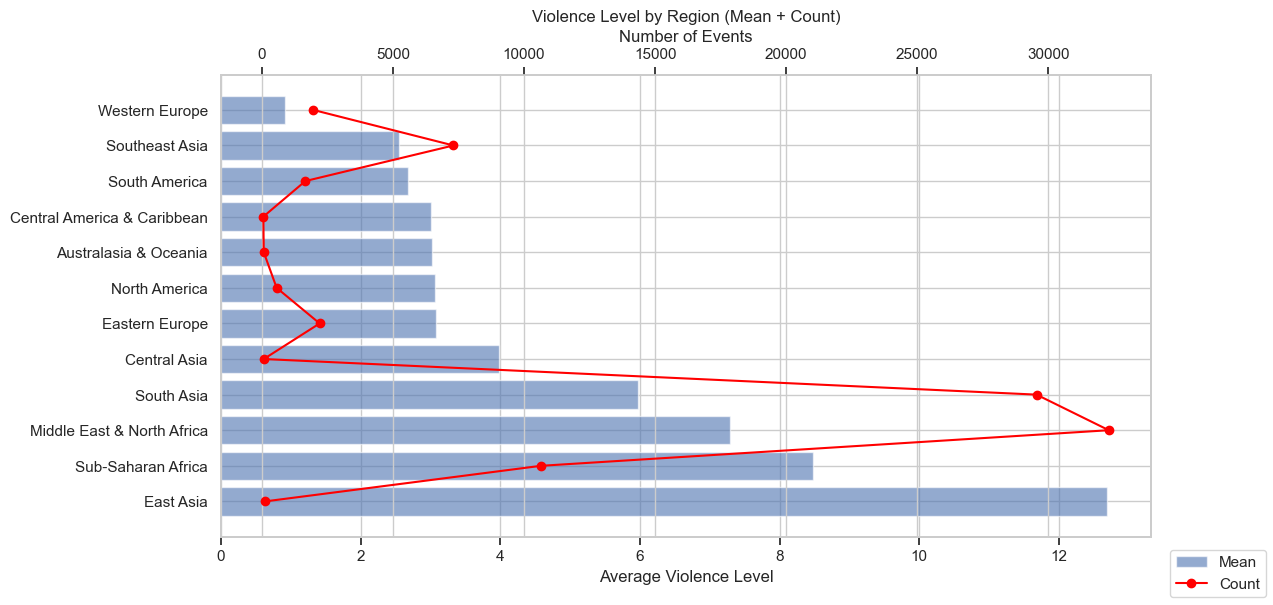

In [37]:
#Building a more complex plot to compare median and mode, and show the relationship between mean and number of attacks. (region)
region_stats = (
    df_trimmed
    .groupby('region_txt')['violence_level']
    .agg(['mean', 'median', 'count'])
)

region_stats = region_stats[region_stats['count'] > 50]

region_stats = region_stats.sort_values('mean', ascending=False)

x = np.arange(len(region_stats))
width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(x - width/2, region_stats['mean'], height=width, label='Mean')
plt.barh(x + width/2, region_stats['median'], height=width, label='Median')

plt.yticks(x, region_stats.index)
plt.xlabel("Violence Level")
plt.title("Mean vs Median Violence Level by Region")

plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Mean bars
ax1.barh(region_stats.index, region_stats['mean'], alpha=0.6, label='Mean')
ax1.set_xlabel("Average Violence Level")

# Second axis for counts
ax2 = ax1.twiny()
ax2.plot(region_stats['count'], region_stats.index, 'o-', color='red', label='Count')
ax2.set_xlabel("Number of Events")

plt.title("Violence Level by Region (Mean + Count)")

fig.legend(loc='lower right')
plt.show()

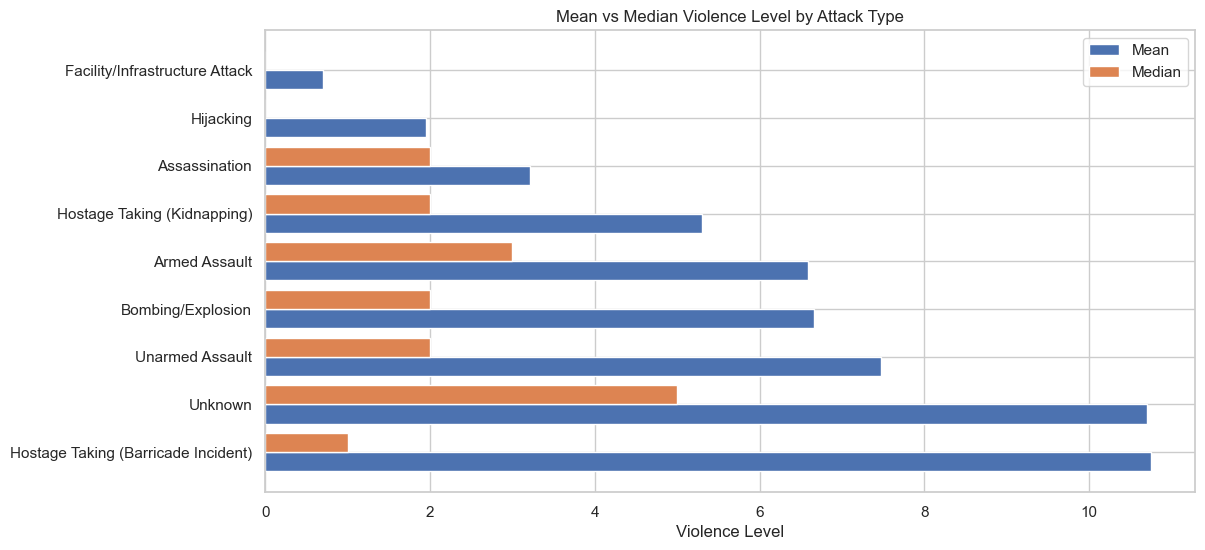

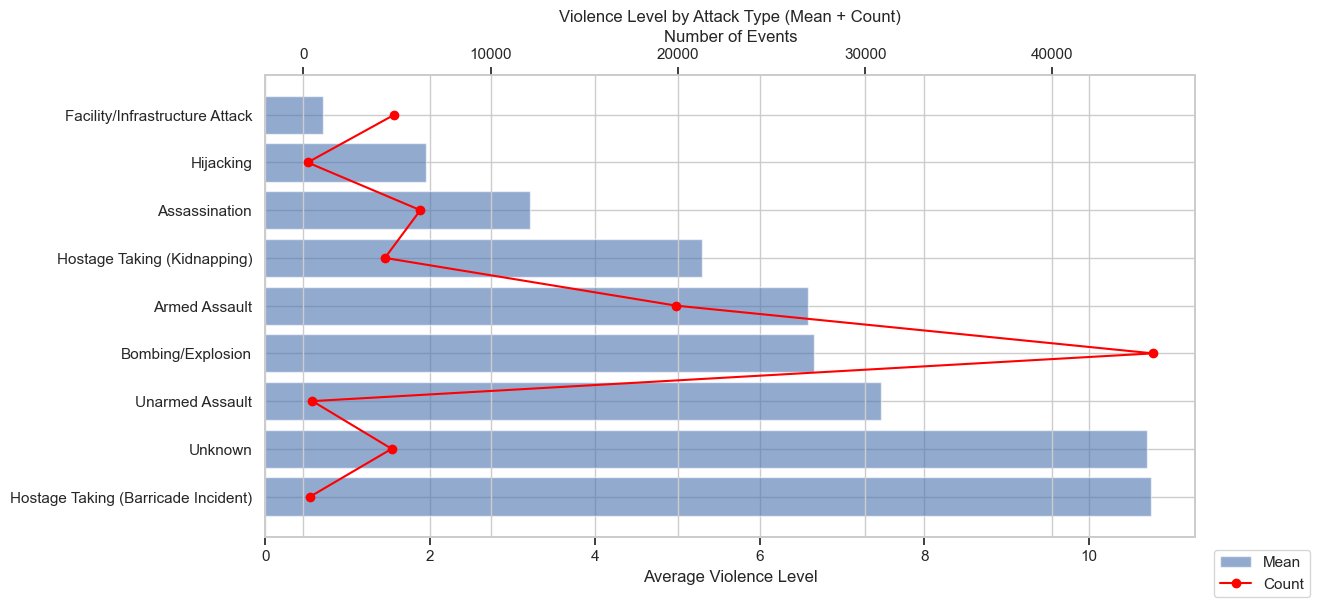

In [39]:
#Building a more complex plot to compare median and mode, and show the relationship between mean and number of attacks. (Attack Type)
attack_stats = (
    df_trimmed
    .groupby('attacktype1_txt')['violence_level']
    .agg(['mean', 'median', 'count'])
)

attack_stats = attack_stats[attack_stats['count'] > 50]

attack_stats = attack_stats.sort_values('mean', ascending=False)

x = np.arange(len(attack_stats))
width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(x - width/2, attack_stats['mean'], height=width, label='Mean')
plt.barh(x + width/2, attack_stats['median'], height=width, label='Median')

plt.yticks(x, attack_stats.index)
plt.xlabel("Violence Level")
plt.title("Mean vs Median Violence Level by Attack Type")

plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Mean bars
ax1.barh(attack_stats.index, attack_stats['mean'], alpha=0.6, label='Mean')
ax1.set_xlabel("Average Violence Level")

# Second axis for counts
ax2 = ax1.twiny()
ax2.plot(attack_stats['count'], attack_stats.index, 'o-', color='red', label='Count')
ax2.set_xlabel("Number of Events")

plt.title("Violence Level by Attack Type (Mean + Count)")

fig.legend(loc='lower right')
plt.show()

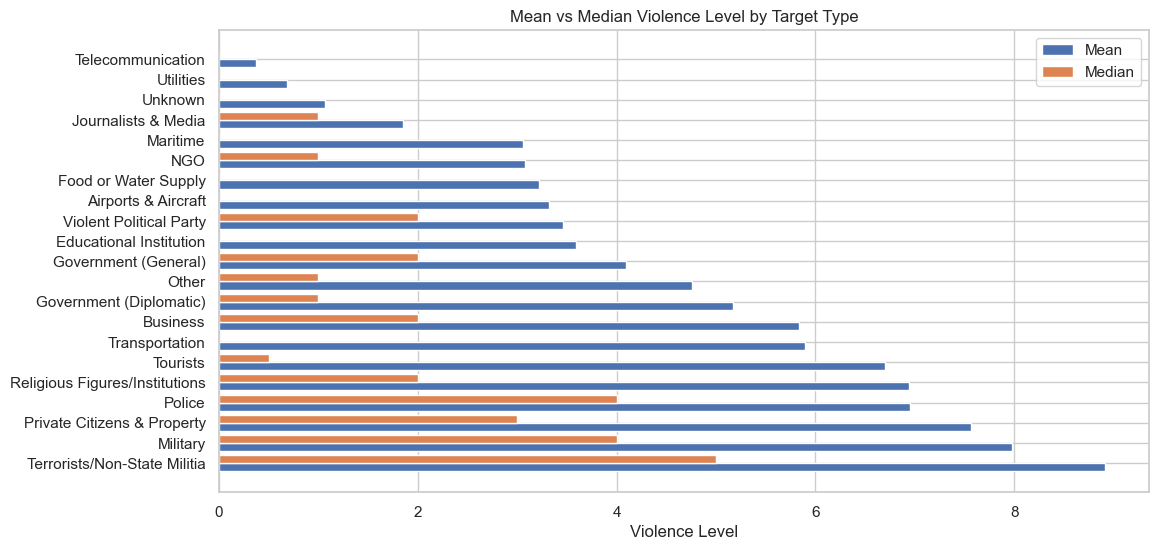

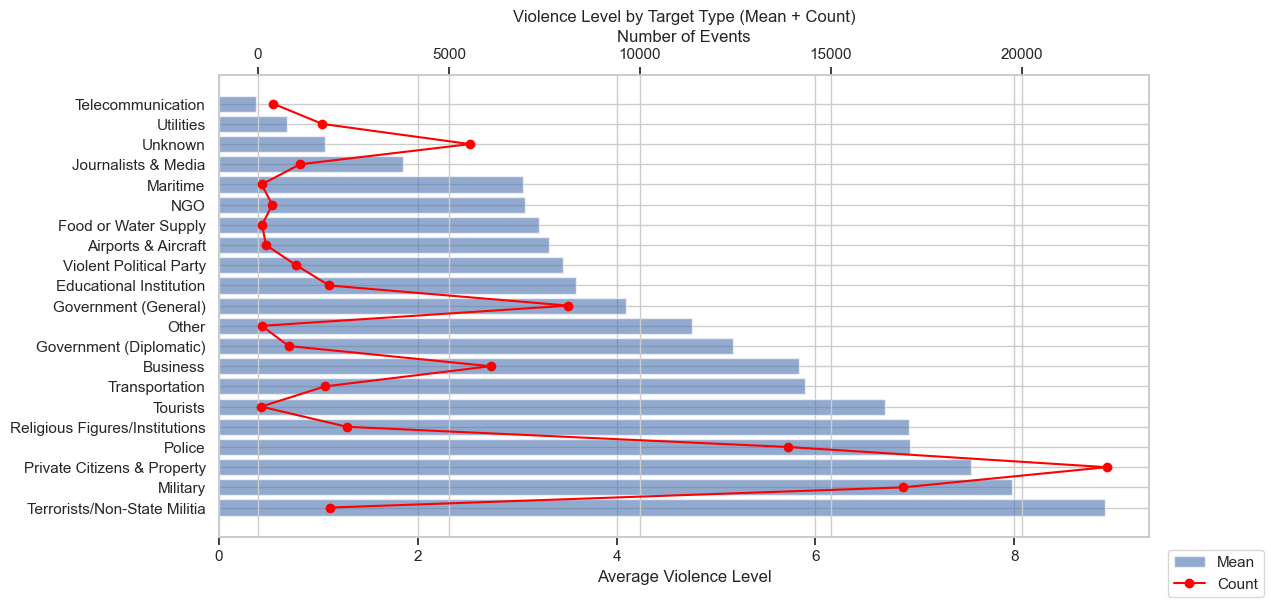

In [40]:
#Building a more complex plot to compare median and mode, and show the relationship between mean and number of attacks. (Target Type)
target_stats = (
    df_trimmed
    .groupby('targtype1_txt')['violence_level']
    .agg(['mean', 'median', 'count'])
)

target_stats = target_stats[target_stats['count'] > 50]

target_stats = target_stats.sort_values('mean', ascending=False)

x = np.arange(len(target_stats))
width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(x - width/2, target_stats['mean'], height=width, label='Mean')
plt.barh(x + width/2, target_stats['median'], height=width, label='Median')

plt.yticks(x, target_stats.index)
plt.xlabel("Violence Level")
plt.title("Mean vs Median Violence Level by Target Type")

plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Mean bars
ax1.barh(target_stats.index, target_stats['mean'], alpha=0.6, label='Mean')
ax1.set_xlabel("Average Violence Level")

# Second axis for counts
ax2 = ax1.twiny()
ax2.plot(target_stats['count'], target_stats.index, 'o-', color='red', label='Count')
ax2.set_xlabel("Number of Events")

plt.title("Violence Level by Target Type (Mean + Count)")

fig.legend(loc='lower right')
plt.show()

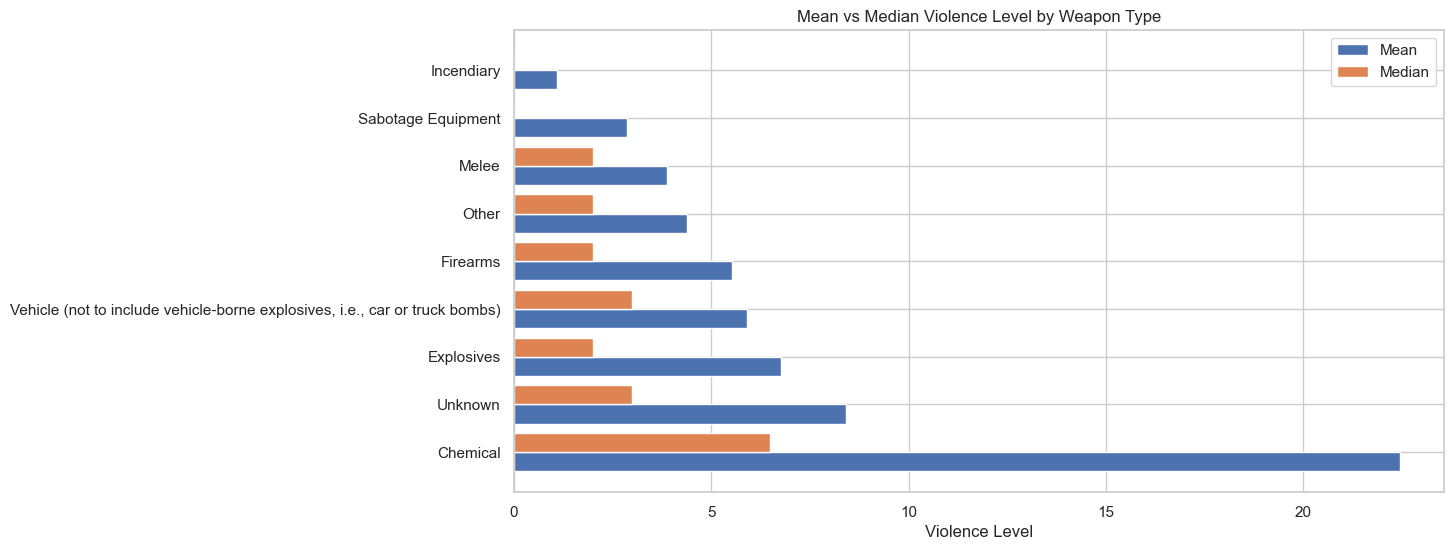

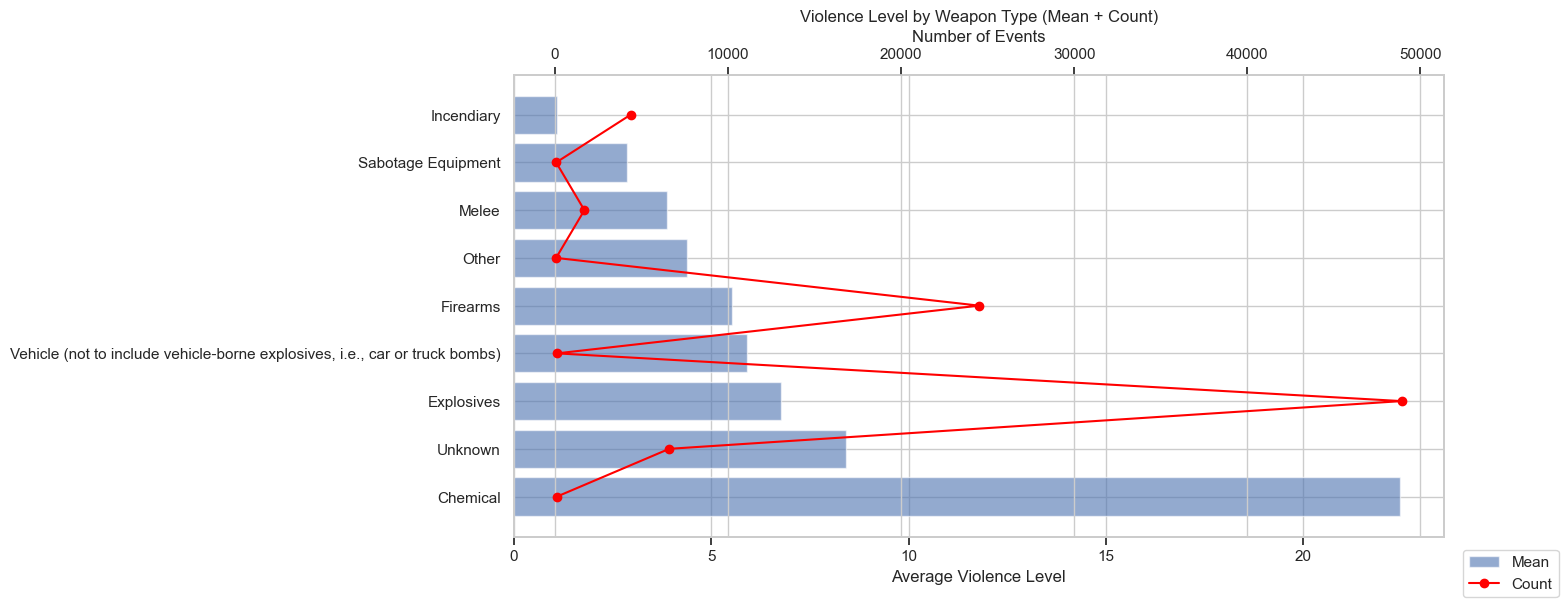

In [41]:
#Building a more complex plot to compare median and mode, and show the relationship between mean and number of attacks. (Weapon Type)
weapon_stats = (
    df_trimmed
    .groupby('weaptype1_txt')['violence_level']
    .agg(['mean', 'median', 'count'])
)

weapon_stats = weapon_stats[weapon_stats['count'] > 50]

weapon_stats = weapon_stats.sort_values('mean', ascending=False)

x = np.arange(len(weapon_stats))
width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(x - width/2, weapon_stats['mean'], height=width, label='Mean')
plt.barh(x + width/2, weapon_stats['median'], height=width, label='Median')

plt.yticks(x, weapon_stats.index)
plt.xlabel("Violence Level")
plt.title("Mean vs Median Violence Level by Weapon Type")

plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Mean bars
ax1.barh(weapon_stats.index, weapon_stats['mean'], alpha=0.6, label='Mean')
ax1.set_xlabel("Average Violence Level")

# Second axis for counts
ax2 = ax1.twiny()
ax2.plot(weapon_stats['count'], weapon_stats.index, 'o-', color='red', label='Count')
ax2.set_xlabel("Number of Events")

plt.title("Violence Level by Weapon Type (Mean + Count)")

fig.legend(loc='lower right')
plt.show()

## Quick look at most active/most violent groups

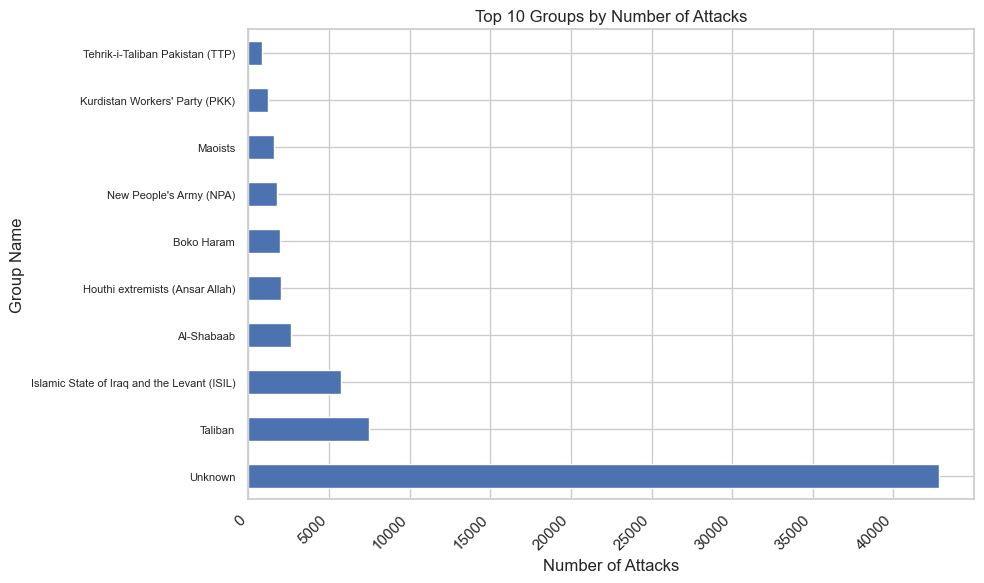

In [45]:
#Make a histogram of the top ten groups by number of attacks
top10_counts = df_trimmed['gname'].value_counts().head(10)
top10_groups = df_trimmed['gname'].value_counts().head(10).index
df_top10 = df_trimmed[df_trimmed['gname'].isin(top10_groups)]

plt.figure(figsize=(10,6))

top10_counts.plot(kind='barh')

plt.xlabel("Number of Attacks")
plt.ylabel("Group Name")
plt.title("Top 10 Groups by Number of Attacks")

plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

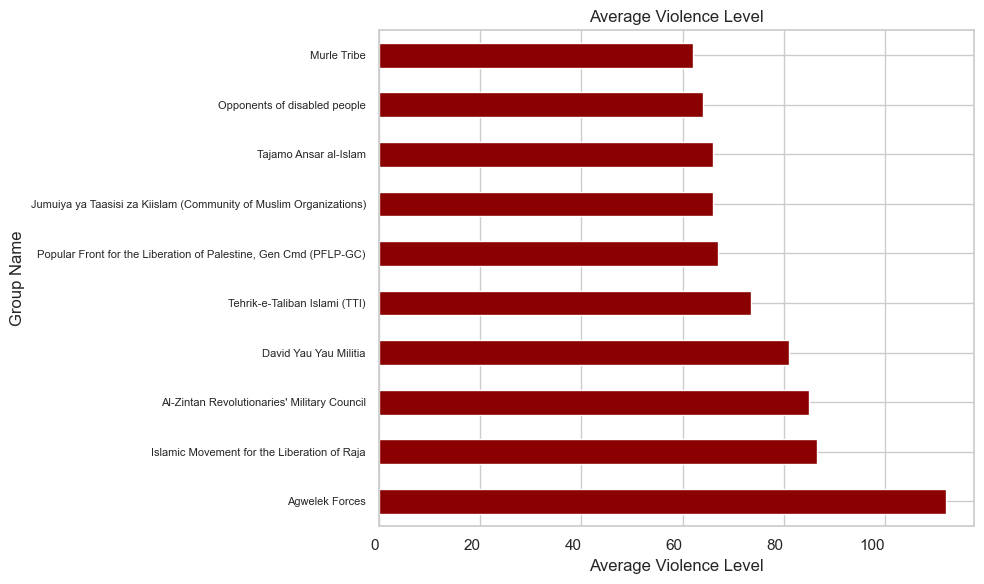

In [47]:
#Make a histogram of the top ten groups by average violence level
top10_violence = (
    df_trimmed
    .groupby('gname')['violence_level']
    .median()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top10_violence.plot(kind='barh', color='darkred')

plt.xlabel("Average Violence Level")
plt.ylabel("Group Name")
plt.title("Average Violence Level")

plt.xticks(rotation=0, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## Grab Summary Statistics

In [50]:
#Pull summary statistics for numerical columns
cols = df_trimmed.select_dtypes(include='object').columns
df_trimmed[cols] = df_trimmed[cols].astype('category')

#Our final columns used in models.
final_cols = df_trimmed[['country_txt', 'region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt',
    'individual','success', 'extended', 'claimed','ishostkid','property','nkill', 'nwound', 'violence_level']]

num_cols = final_cols.select_dtypes(include='number').columns
final_cols[num_cols].describe().round(4)

C:\Users\alist\AppData\Local\Temp\ipykernel_23776\126581927.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trimmed[cols] = df_trimmed[cols].astype('category')


,individual,success,extended,claimed,ishostkid,property,nkill,nwound,violence_level
count,86497.0000,86497.0000,86497.0000,86497.0000,86497.0000,86497.0000,86497.0000,86497.0000,86497.0000
mean,0.0054,0.8402,0.0321,0.1856,0.0567,0.3582,1.8271,2.5662,6.2204
std,0.0730,0.3664,0.1764,0.3888,0.2313,0.4795,4.1477,6.4060,12.5572
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,2.0000
75%,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,2.0000,3.0000,6.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,72.0000,140.0000,146.0000


In [70]:
#Pull summary statistics for categorical columns. I tried to make this a bit prettier, but couldn't find a way in notebook
def cat_summary_styled(df, col):
    vc = df[col].value_counts()
    
    summary = pd.DataFrame({
        "Count": vc,
        "Percent (%)": (vc / vc.sum() * 100)
    }).round(2)
    
    return summary.style.format({
        "Count": "{:,}",
        "Percent (%)": "{:.2f}%"
    })

print(df['country_txt'].value_counts().head(15))

cols = final_cols.select_dtypes(include='category').columns
for col in cols:
    display(cat_summary_styled(df_trimmed, col))
    print("\n\n")

country_txt
Iraq              26755
Afghanistan       16313
Pakistan          15208
India             13477
Colombia           8742
Philippines        7976
Peru               6109
Yemen              5526
United Kingdom     5424
El Salvador        5320
Nigeria            5070
Somalia            5037
Turkey             4464
Thailand           4162
Spain              3255
Name: count, dtype: int64


,Count,Percent (%)
country_txt,,
Iraq,"17,792",20.57%
Afghanistan,"12,130",14.02%
Pakistan,"9,356",10.82%
India,"6,247",7.22%
Philippines,"4,423",5.11%
Yemen,"4,073",4.71%
Nigeria,"3,079",3.56%
Somalia,"2,846",3.29%
Thailand,"2,258",2.61%


,Count,Percent (%)
region_txt,,
Middle East & North Africa,"32,310",37.35%
South Asia,"29,552",34.17%
Sub-Saharan Africa,"10,646",12.31%
Southeast Asia,"7,306",8.45%
Eastern Europe,"2,202",2.55%
Western Europe,"1,950",2.25%
South America,"1,657",1.92%
North America,561,0.65%
East Asia,118,0.14%


,Count,Percent (%)
attacktype1_txt,,
Bombing/Explosion,"45,373",52.46%
Armed Assault,"19,904",23.01%
Assassination,"6,243",7.22%
Facility/Infrastructure Attack,"4,853",5.61%
Unknown,"4,712",5.45%
Hostage Taking (Kidnapping),"4,349",5.03%
Unarmed Assault,478,0.55%
Hostage Taking (Barricade Incident),364,0.42%
Hijacking,221,0.26%


,Count,Percent (%)
targtype1_txt,,
Private Citizens & Property,"22,217",25.69%
Military,"16,883",19.52%
Police,"13,877",16.04%
Government (General),"8,126",9.39%
Business,"6,086",7.04%
Unknown,"5,550",6.42%
Religious Figures/Institutions,"2,327",2.69%
Terrorists/Non-State Militia,"1,875",2.17%
Educational Institution,"1,861",2.15%


,Count,Percent (%)
weaptype1_txt,,
Explosives,"48,914",56.55%
Firearms,"24,507",28.33%
Unknown,"6,606",7.64%
Incendiary,"4,374",5.06%
Melee,"1,705",1.97%
Chemical,124,0.14%
"Vehicle (not to include vehicle-borne explosives, i.e., car or truck bombs)",118,0.14%
Sabotage Equipment,73,0.08%
Other,69,0.08%
